# Análise de impactos nas vendas da Lamborghini (2020-2025) 
----------------------------------------------------------------------------------------

Análise exploratória do dataset que mostra as vendas dos carros Lamborghini entre 2020 e 2025, a fim de entender como se constrói a receita da 
empresa, fatores que impactam a receita e possíveis pontos de atenção.

----------------------------------------------------------------------------------------
#### Anna Paula Viana Campelo Mendes
##### Analista de Dados

----------------------------------------------------------------------------------------

## Principal Análise

Quais fatores mais impactam a receita da Lamborghini entre 2020 e 2025?

----------------------------------------------------------------------------------------

### Análises de Suporte

Como se constrói a receita da Lamborghini?
Existe algum fator de forte impacto na receita?
Quais pontos que constroem a receita merecem atenção?

----------------------------------------------------------------------------------------

### Estrutura da análise dos dados

A fim de entender melhor a receita, serão feitas análises mais gerais do volume de vendas, mas para entender de forma mais profunda, os dados serão segmentados em modelos de carros e região do mundo.
Assim, procura-se responder essas questões:

Como o volume de vendas se comporta ano após ano?
Como o volume de vendas se distribui entre os modelos de carros e regiões?
Existe algum impacto forte na receita a partir de um modelo ou região?

----------------------------------------------------------------------------------------

#### Início do EDA

----------------------------------------------------------------------------------------

In [1]:
## Importando as bibliotecas ##

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

In [2]:
## Criando o dataframe e lendo as primeiras linhas ##

df = pd.read_csv('lamborghini_sales_2020_2025.csv')
df.head()

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo (Yes/No)
0,Urus,2020,EMEA,Black,Gasoline,230000,641,4500,Yes
1,Urus,2020,Americas,White,Gasoline,240000,641,4800,Yes
2,Urus,2020,APAC,Red,Gasoline,235000,641,2700,Yes
3,Huracán,2020,EMEA,Yellow,Gasoline,260000,631,2500,Yes
4,Huracán,2020,Americas,Orange,Gasoline,270000,631,2600,Yes


In [ ]:
## Entendendo as colunas ##

# Model: Modelo do carro.
# Year: Ano da venda.
# Region: Região do mundo onde foi feita a venda.
# Color: Cor do carro.
# Fuel Type: Tipo de combustível.
# Base Price (USD): Preço base em dólares americanos.
# Horsepower: Potência do carro em cavalos.
# Sales Volume: Volumes de venda daquela transação.
# Turbo: Se o carro possui turbo (Y/N).

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Model             54 non-null     object
 1   Year              54 non-null     int64 
 2   Region            54 non-null     object
 3   Color             54 non-null     object
 4   Fuel Type         54 non-null     object
 5   Base Price (USD)  54 non-null     int64 
 6   Horsepower        54 non-null     int64 
 7   Sales Volume      54 non-null     int64 
 8   Turbo (Yes/No)    54 non-null     object
dtypes: int64(4), object(5)
memory usage: 3.9+ KB


In [3]:
cols = [col for col in df.columns 
        if col not in ['Base Price (USD)', 'Sales Volume']]

for col in cols:
    print(f"\nColuna: {col}")
    print(df[col].unique())

## Justificativa da exclusão das colunas da análise: Se o dataset fosse muito grande, com muitas linhas, 
## essas colunas teriam muitos valores diferentes e isso geraria dados difíceis de ler e que não fariam sentido.


Coluna: Model
['Urus' 'Huracán' 'Aventador' 'Revuelto' 'Urus SE' 'Huracán (Temerario)']

Coluna: Year
[2020 2021 2022 2023 2024 2025]

Coluna: Region
['EMEA' 'Americas' 'APAC']

Coluna: Color
['Black' 'White' 'Red' 'Yellow' 'Orange' 'Silver' 'Blue' 'Green' 'Grey']

Coluna: Fuel Type
['Gasoline' 'Hybrid']

Coluna: Horsepower
[ 641  631  769 1001  850]

Coluna: Turbo (Yes/No)
['Yes']


In [4]:
## Verificando se existem dados nulos ##

df.isnull().sum()

Model               0
Year                0
Region              0
Color               0
Fuel Type           0
Base Price (USD)    0
Horsepower          0
Sales Volume        0
Turbo (Yes/No)      0
dtype: int64

In [5]:
## Verificando se existem linhas duplicadas ##

df.duplicated().sum()

np.int64(0)

----------------------------------------------------------------------------------------

#### É possível observar que o dataset está limpo, sendo assim, não é necessário realizar um data cleaning.

----------------------------------------------------------------------------------------

In [6]:
df.describe()

,Year,Base Price (USD),Horsepower,Sales Volume
count,54.000000,54.000000,54.000000,54.000000
mean,2022.500000,374722.222222,718.277778,2618.037037
std,1.723861,136293.304237,121.645234,1785.625201
min,2020.000000,230000.000000,631.000000,63.000000
25%,2021.000000,265000.000000,631.000000,1187.500000
50%,2022.500000,300000.000000,641.000000,2543.000000
75%,2024.000000,550000.000000,769.000000,3896.500000
max,2025.000000,590000.000000,1001.000000,6200.000000


----------------------------------------------------------------------------------------

### Início da criação dos gráficos e análises.

A partir deste momento, serão criados gráficos e outras análises afim de responder as perguntas feitas no início.

----------------------------------------------------------------------------------------

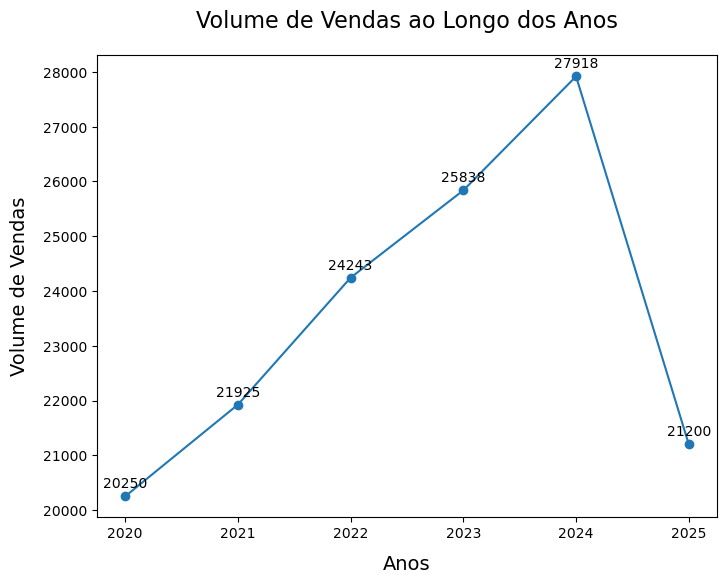

In [7]:
## Primeira análise: Análise do total de vendas ano após ano? ##


fig, ax = plt.subplots(figsize=(8, 6))

sales_by_year = df.groupby('Year')['Sales Volume'].sum()
ax.plot(sales_by_year.index, sales_by_year.values, marker='o')

ax.set_title('Volume de Vendas ao Longo dos Anos', fontsize=16, pad=20)
ax.set_xlabel('Anos', fontsize=14, labelpad=10)
ax.set_ylabel('Volume de Vendas', fontsize=14, labelpad=10)


for x, y in zip(sales_by_year.index, sales_by_year.values):
    ax.annotate(
        f'{y}',
        (x, y),
        textcoords="offset points",
        xytext=(0, 6), 
        ha='center'
    )

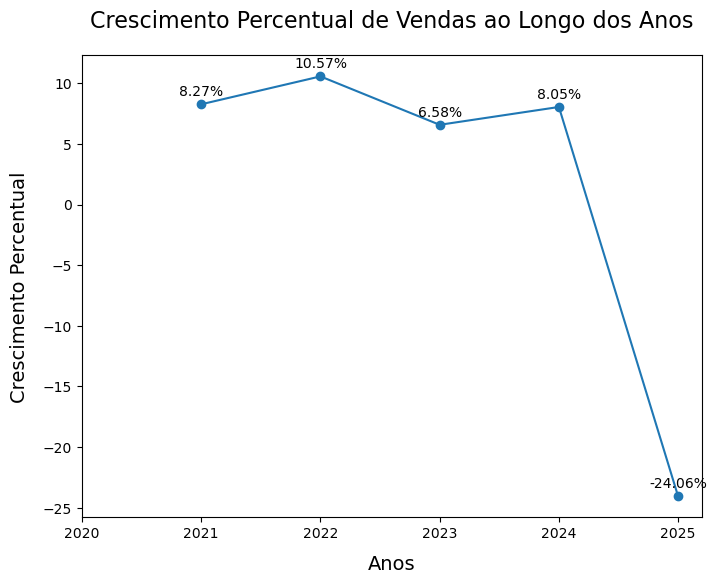

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

df_ano = (
    df.groupby('Year')['Sales Volume']
      .sum()
      .sort_index()
      .pct_change() * 100
)
df_ano.index = df_ano.index.astype(int)

ax.plot(df_ano.index, df_ano.values, marker='o')
ax.set_xticks(df_ano.index)

ax.set_title('Crescimento Percentual de Vendas ao Longo dos Anos', fontsize=16, pad=20)
ax.set_xlabel('Anos', fontsize=14, labelpad=10)
ax.set_ylabel('Crescimento Percentual', fontsize=14, labelpad=10)

# adicionando os labels nos pontos
for x, y in zip(df_ano.index, df_ano.values):
    ax.annotate(
        f'{y:.2f}%',
        (x, y),
        textcoords="offset points",
        xytext=(0, 6),  
        ha='center'
    )

----------------------------------------------------------------------------------------

### Primeiras análises: Análise temporal da evolução do percentual de vendas.

Existe uma queda significativa de 24% no volume de vendas a partir de 2025.
Como esse número é expressivo, vamos investigar mais a fundo afim de descobrir quais pontos mais impactam essa queda.

----------------------------------------------------------------------------------------

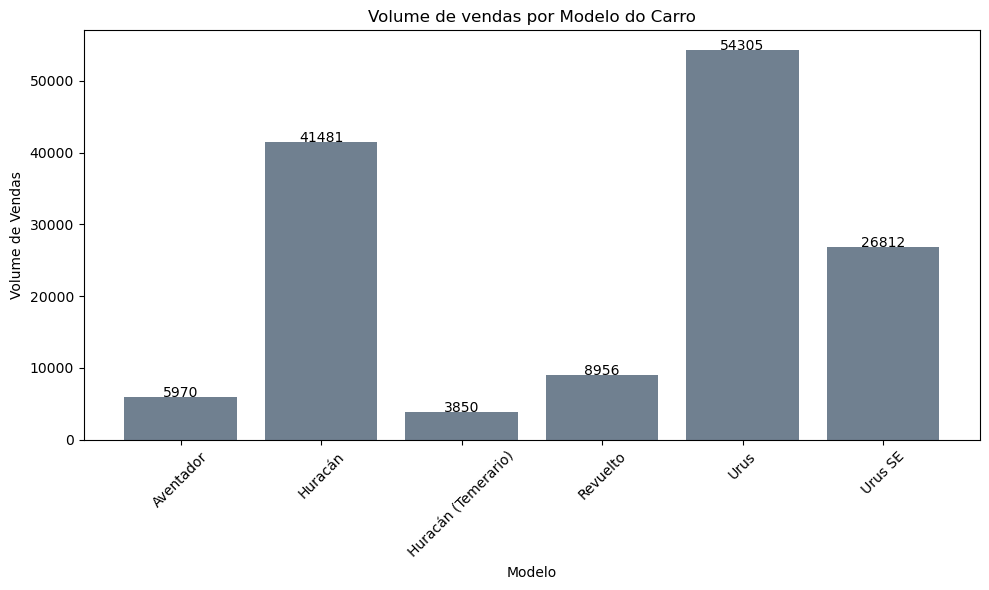

In [9]:
## Segunda análise ##
## Análise do total de vendas ano após ano segmentado por modelo de carro? ##


models_by_year = df.groupby('Model')['Sales Volume'].sum()

plt.figure(figsize=(10,6))
plt.bar(models_by_year.index, models_by_year.values, color='slategray')

for x, y in zip(models_by_year.index, models_by_year.values):
    plt.text(x, y + 5, str(y), ha='center')

plt.xlabel('Modelo')
plt.ylabel('Volume de Vendas')
plt.title('Volume de vendas por Modelo do Carro')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------

### Segunda análise: Distribuição do volume de vendas segmentado por modelo de carro.

O volume de vendas está concentrado em três principais modelos, Huracán, Urus e Urus SE, isto sugere que a receita depende majoritariamente destes. 
Como os demais modelos apresentam um volume menor, se comparado àqueles três, para facilitar as análises, esses serão agrupados como "Outros".

----------------------------------------------------------------------------------------

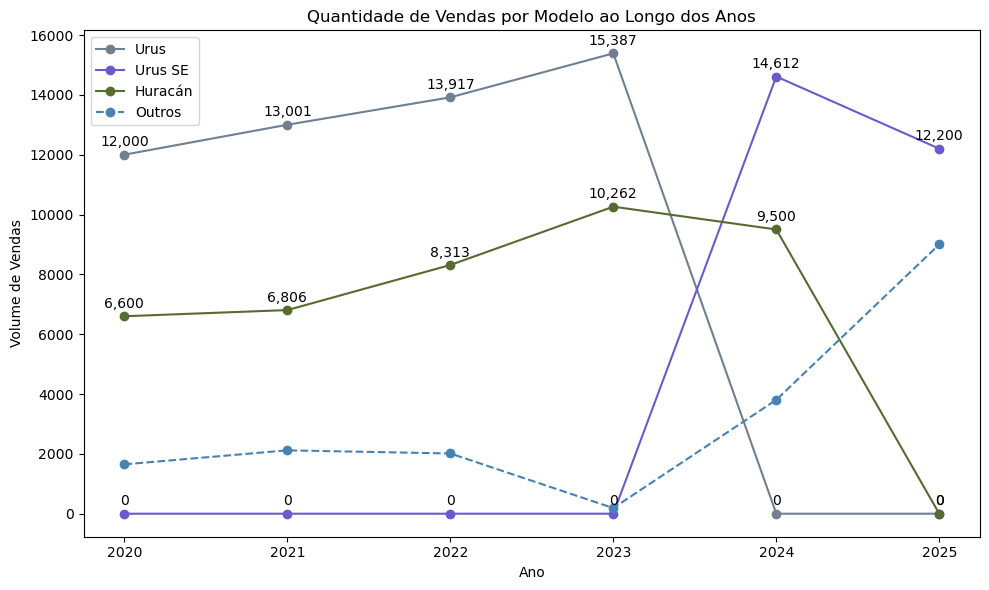

In [10]:
modelos_principais = ['Urus', 'Urus SE', 'Huracán']
cores = ['slategray', 'slateblue', 'darkolivegreen', 'steelblue']


df_temp = df.copy()


df_temp['Model'] = df_temp['Model'].where(
    df_temp['Model'].isin(modelos_principais),
    'Outros'
)


df_pivot = df_temp.pivot_table(
    index='Year',
    columns='Model',
    values='Sales Volume',
    aggfunc='sum'
).fillna(0)


df_pivot.index = df_pivot.index.astype(int)


plt.figure(figsize=(10,6))


for i, modelo in enumerate(modelos_principais):
    if modelo in df_pivot.columns:
        plt.plot(
            df_pivot.index,
            df_pivot[modelo],
            marker='o',
            label=modelo,
            color=cores[i]
        )

        
        for x, y in zip(df_pivot.index, df_pivot[modelo]):
            plt.annotate(
                f'{y:,.0f}',
                (x, y),
                textcoords="offset points",
                xytext=(0, 6),
                ha='center'
            )


if 'Outros' in df_pivot.columns:
    plt.plot(
        df_pivot.index,
        df_pivot['Outros'],
        marker='o',
        linestyle='--',
        label='Outros',
        color=cores[-1]
    )


plt.xlabel('Ano')
plt.ylabel('Volume de Vendas')
plt.title('Quantidade de Vendas por Modelo ao Longo dos Anos')
plt.legend()

plt.xticks(df_pivot.index)
plt.tight_layout()
plt.show()

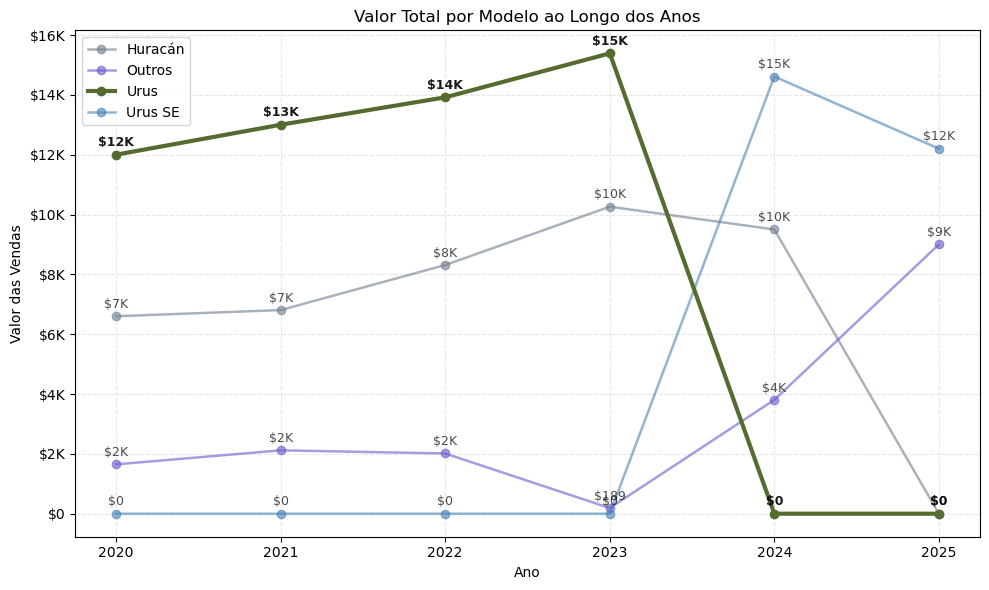

In [11]:
## Análise do Volume de Vendas por Modelo de carro ao longo dos anos ##


modelos_principais = ['Urus', 'Urus SE', 'Huracán']
cores = ['slategray', 'slateblue', 'darkolivegreen', 'steelblue']


def formatar_valor(x, _):
    if x >= 1e6:
        return f'${x/1e6:.1f}M'
    elif x >= 1e3:
        return f'${x/1e3:.0f}K'
    else:
        return f'${x:.0f}'


def format_label(y):
    if y >= 1e6:
        return f'${y/1e6:.1f}M'
    elif y >= 1e3:
        return f'${y/1e3:.0f}K'
    else:
        return f'${y:.0f}'

fig, ax = plt.subplots(figsize=(10,6))

modelos = df_pivot.columns


modelo_destaque = df_pivot.sum().idxmax()

for i, modelo in enumerate(modelos):
    y = df_pivot[modelo]
    
    # destaca o melhor modelo
    if modelo == modelo_destaque:
        linewidth = 3
        alpha = 1
        zorder = 3
    else:
        linewidth = 1.8
        alpha = 0.6
        zorder = 2
    
    ax.plot(
        df_pivot.index,
        y,
        marker='o',
        label=modelo,
        color=cores[i],
        linewidth=linewidth,
        alpha=alpha,
        zorder=zorder
    )
    
    for x, y_val in zip(df_pivot.index, y):
        ax.annotate(
            format_label(y_val),
            (x, y_val),
            textcoords="offset points",
            xytext=(0, 6),
            ha='center',
            fontsize=9,
            weight='bold' if modelo == modelo_destaque else 'normal',
            alpha=0.9 if modelo == modelo_destaque else 0.7
        )


ax.yaxis.set_major_formatter(mtick.FuncFormatter(formatar_valor))


ax.set_xticks(df_pivot.index)
ax.set_xticklabels(df_pivot.index.astype(int))


ax.grid(True, linestyle='--', alpha=0.3)


ax.set_xlabel('Ano')
ax.set_ylabel('Valor das Vendas')
ax.set_title('Valor Total por Modelo ao Longo dos Anos')


ax.legend()

plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------

### Terceira Análise: Análise temporal da distribuição das vendas e receita segmentado por modelos de carros.

As categorias analisadas consolidam o pensamento de que a receita se concentra nos três modelos citados anteriormente. 
Assim, inconstâncias no volume de vendas desses modelos devem ser investigadas, pois representam grandes mudanças nas receitas.

----------------------------------------------------------------------------------------

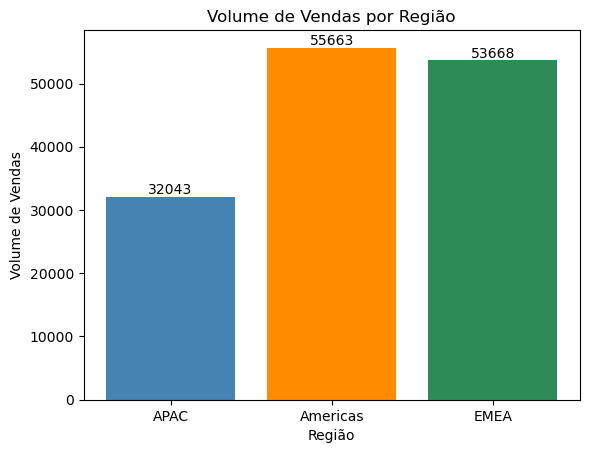

In [12]:
## Quarta Análise ##
## Análise do total de vendas ano após ano segmentado por região? #


sales_by_region = df.groupby('Region')['Sales Volume'].sum()

cores = ['steelblue', 'darkorange', 'seagreen']  # uma cor por região

bars = plt.bar(sales_by_region.index, sales_by_region.values, color=cores)

# Labels nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.xlabel('Região')
plt.ylabel('Volume de Vendas')
plt.title('Volume de Vendas por Região')
plt.show()

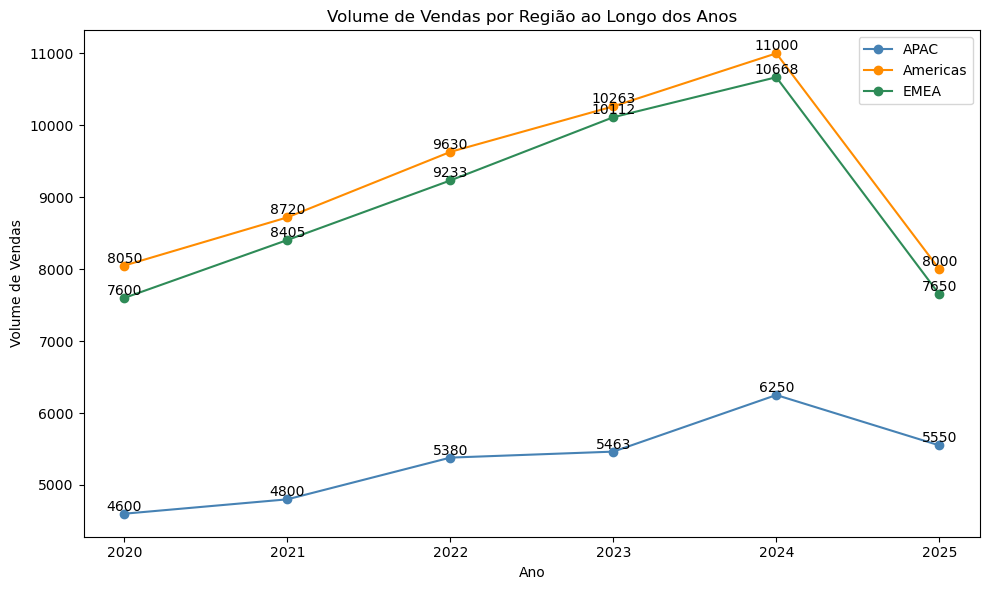

In [15]:
## Análise do Volume de Vendas por Região ao longo dos anos. ##


df_pivot2 = df.pivot_table(
    index='Year',
    columns='Region',
    values='Sales Volume',
    aggfunc='sum'
).fillna(0)

df_pivot2.index = df_pivot2.index.astype(int)

plt.figure(figsize=(10,6))

cores = ['steelblue', 'darkorange', 'seagreen']

for i, regiao in enumerate(df_pivot2.columns):
    plt.plot(
        df_pivot2.index,
        df_pivot2[regiao],
        marker='o',
        label=regiao,
        color=cores[i % len(cores)]
    )

    # labels em todos os pontos
    for x, y in zip(df_pivot2.index, df_pivot2[regiao]):
        plt.text(
            x, y,
            f'{int(y)}',
            ha='center',
            va='bottom'
        )

plt.xlabel('Ano')
plt.ylabel('Volume de Vendas')
plt.title('Volume de Vendas por Região ao Longo dos Anos')
plt.legend()

plt.xticks(df_pivot2.index)
plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------

#### Quarta Análise: Análise temporal do volume de vendas segmentado por região.

As regiões Americas e EMEA representam o maior volume de vendas, mas mostram um comportamento que indica decrescimento e, aliado à isso, um forte impacto na receita.
De forma geral, o volume de vendas apresenta uma queda de 24% a partir de 2024, especialmente nas regiões Americas e EMEA.
Sendo assim, essas duas regiões serão analisadas mais detalhadamente, a fim de investigar melhor estes números.

----------------------------------------------------------------------------------------

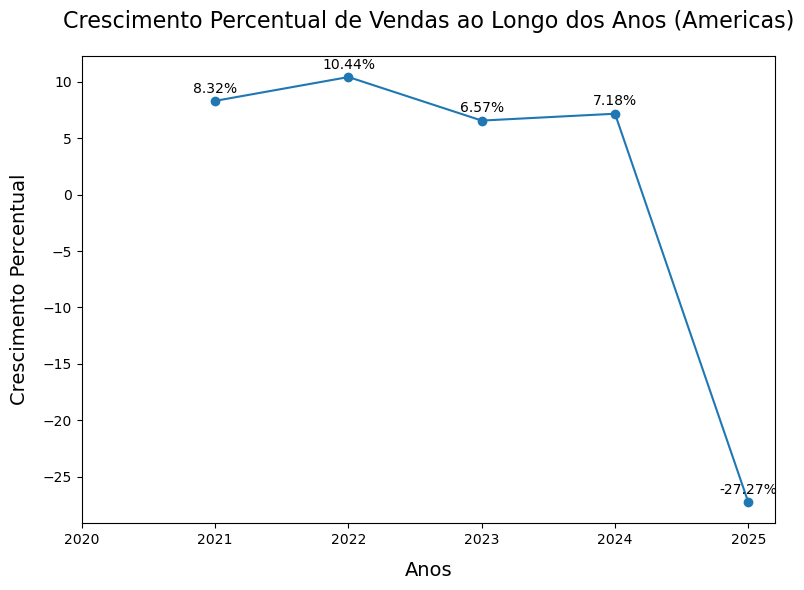

In [16]:
## Analisando primeiro a região Americas. ##
## Repetição da análise de crescimento percentual, focado na região Americas. ##


fig, ax = plt.subplots(figsize=(8, 6))


df_filtrado = df[df['Region'] == 'Americas']

df_ano = (
    df_filtrado.groupby('Year')['Sales Volume']
      .sum()
      .sort_index()
      .pct_change() * 100
)

df_ano.index = df_ano.index.astype(int)

ax.plot(df_ano.index, df_ano.values, marker='o')
ax.set_xticks(df_ano.index)

ax.set_title('Crescimento Percentual de Vendas ao Longo dos Anos (Americas)', fontsize=16, pad=20)
ax.set_xlabel('Anos', fontsize=14, labelpad=10)
ax.set_ylabel('Crescimento Percentual', fontsize=14, labelpad=10)


for x, y in zip(df_ano.index, df_ano.values):
    ax.annotate(
        f'{y:.2f}%',
        (x, y),
        textcoords="offset points",
        xytext=(0, 6),
        ha='center'
    )

plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------

#### Análise mais profunda do crescimento de vendas percentual da região Americas.

Pode-se observar uma quedas de 27% no volume de vendas, o que confirma que esta região tem impacto forte na receita da empresa.
Agora vamos analisar o número do volume de vendas dos modelos de carro, para observar melhor quais modelos impactaram o volume de vendas.

----------------------------------------------------------------------------------------

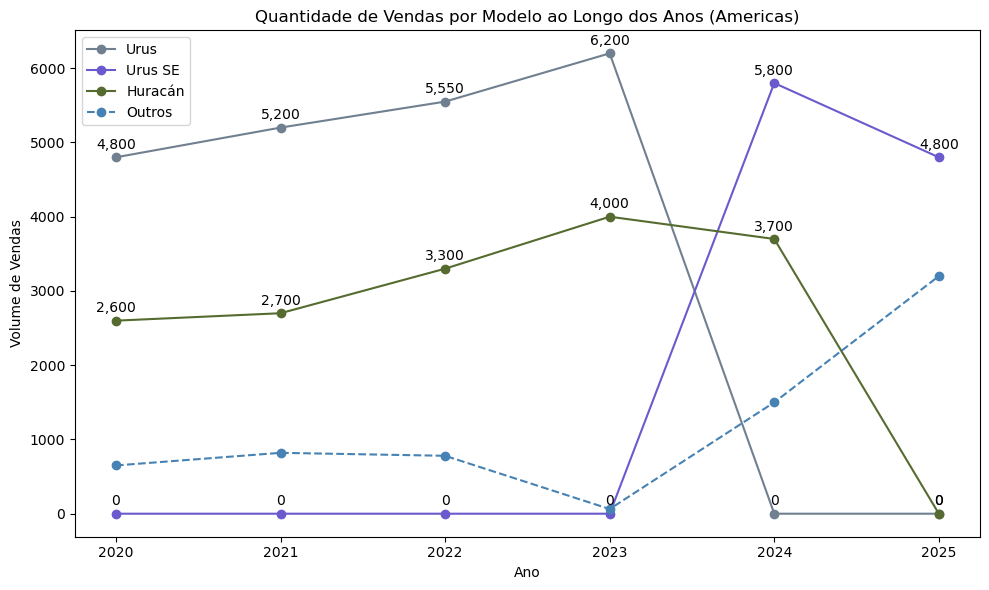

In [17]:
modelos_principais = ['Urus', 'Urus SE', 'Huracán']
cores = ['slategray', 'slateblue', 'darkolivegreen', 'steelblue']

df_temp = df.copy()


df_temp = df_temp[df_temp['Region'] == 'Americas']


df_temp['Model'] = df_temp['Model'].where(
    df_temp['Model'].isin(modelos_principais),
    'Outros'
)


df_pivot = df_temp.pivot_table(
    index='Year',
    columns='Model',
    values='Sales Volume',
    aggfunc='sum'
).fillna(0)

df_pivot.index = df_pivot.index.astype(int)


plt.figure(figsize=(10,6))

for i, modelo in enumerate(modelos_principais):
    if modelo in df_pivot.columns:
        plt.plot(
            df_pivot.index,
            df_pivot[modelo],
            marker='o',
            label=modelo,
            color=cores[i]
        )

        for x, y in zip(df_pivot.index, df_pivot[modelo]):
            plt.annotate(
                f'{y:,.0f}',
                (x, y),
                textcoords="offset points",
                xytext=(0, 6),
                ha='center'
            )


if 'Outros' in df_pivot.columns:
    plt.plot(
        df_pivot.index,
        df_pivot['Outros'],
        marker='o',
        linestyle='--',
        label='Outros',
        color=cores[-1]
    )

plt.xlabel('Ano')
plt.ylabel('Volume de Vendas')
plt.title('Quantidade de Vendas por Modelo ao Longo dos Anos (Americas)')
plt.legend()

plt.xticks(df_pivot.index)
plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------

#### Huracán, Urus e Urus SE concentram a receita da região Americas mas apresentam comportamento que deve ser investigado melhor.

Até 2023, os modelos Urus e Huracán dominam o mercado, porém, a partir deste ano, o panorama muda, pois Urus deixa de realizar vendas, cedendo espaço para Urus SE. Já a partir de 2024, vemos uma queda nas vendas do Huracán e um aumento de vendas na categoria "Outros".

Os números dos modelos Urus e Urus SE podem indicar uma descontinuação do primeiro modelo e o início das vendas do segundo, entretanto, não pode-se afirmar isso utilizando somente esse dataset. 

#### Agora essa análise feita acima será repetida para a região EMEA.

----------------------------------------------------------------------------------------

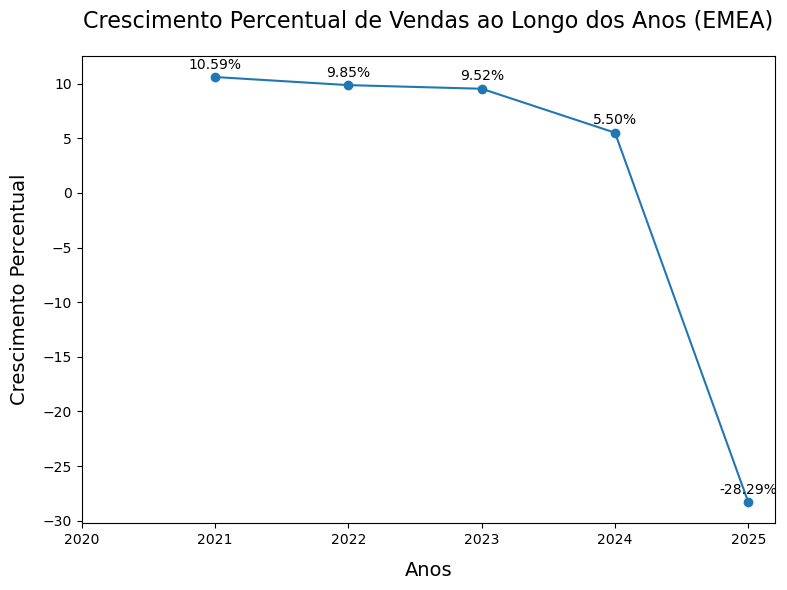

In [18]:
## Analisando a região EMEA. ##
## Repetição da análise de crescimento percentual, focado na região EMEA. ##


fig, ax = plt.subplots(figsize=(8, 6))


df_filtrado = df[df['Region'] == 'EMEA']

df_ano = (
    df_filtrado.groupby('Year')['Sales Volume']
      .sum()
      .sort_index()
      .pct_change() * 100
)

df_ano.index = df_ano.index.astype(int)

ax.plot(df_ano.index, df_ano.values, marker='o')
ax.set_xticks(df_ano.index)

ax.set_title('Crescimento Percentual de Vendas ao Longo dos Anos (EMEA)', fontsize=16, pad=20)
ax.set_xlabel('Anos', fontsize=14, labelpad=10)
ax.set_ylabel('Crescimento Percentual', fontsize=14, labelpad=10)


for x, y in zip(df_ano.index, df_ano.values):
    ax.annotate(
        f'{y:.2f}%',
        (x, y),
        textcoords="offset points",
        xytext=(0, 6),
        ha='center'
    )

plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------

#### Para esta região vê-se um comportamento parecido, onde a queda no volume de vendas foi ainda maior, de 28,3%. ##

Vamos repetir a visão de vendas dos modelos para observar melhor.

----------------------------------------------------------------------------------------

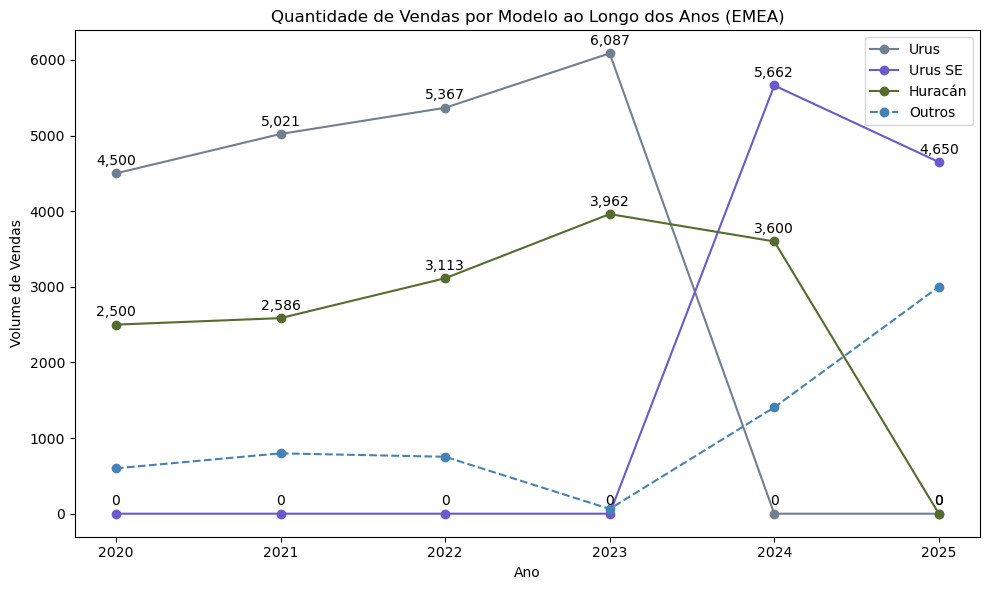

In [19]:
modelos_principais = ['Urus', 'Urus SE', 'Huracán']
cores = ['slategray', 'slateblue', 'darkolivegreen', 'steelblue']

df_temp = df.copy()


df_temp = df_temp[df_temp['Region'] == 'EMEA']


df_temp['Model'] = df_temp['Model'].where(
    df_temp['Model'].isin(modelos_principais),
    'Outros'
)


df_pivot = df_temp.pivot_table(
    index='Year',
    columns='Model',
    values='Sales Volume',
    aggfunc='sum'
).fillna(0)

df_pivot.index = df_pivot.index.astype(int)


plt.figure(figsize=(10,6))

for i, modelo in enumerate(modelos_principais):
    if modelo in df_pivot.columns:
        plt.plot(
            df_pivot.index,
            df_pivot[modelo],
            marker='o',
            label=modelo,
            color=cores[i]
        )

        for x, y in zip(df_pivot.index, df_pivot[modelo]):
            plt.annotate(
                f'{y:,.0f}',
                (x, y),
                textcoords="offset points",
                xytext=(0, 6),
                ha='center'
            )


if 'Outros' in df_pivot.columns:
    plt.plot(
        df_pivot.index,
        df_pivot['Outros'],
        marker='o',
        linestyle='--',
        label='Outros',
        color=cores[-1]
    )

plt.xlabel('Ano')
plt.ylabel('Volume de Vendas')
plt.title('Quantidade de Vendas por Modelo ao Longo dos Anos (EMEA)')
plt.legend()

plt.xticks(df_pivot.index)
plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------

#### Pode-se observar o mesmo comportamento de mercado que na região Americas, dessa forma, pode-se tirar conclusões parecidas. ##

----------------------------------------------------------------------------------------

In [21]:
## Quinta Análise ##
## Análise de preferências de vendas por região: cores, modelos, tipo de combustível e potência do motor. ##


pivot = df.pivot_table(
    index='Color',
    columns='Region',
    values='Sales Volume',
    aggfunc='sum',
    fill_value=0
)

print(pivot)

Region   APAC  Americas   EMEA
Color                         
Black   11070     10000  23830
Blue        0      1800   1406
Green     900         0      0
Grey        0         0   1300
Orange      0     17700      0
Red     13393         0   1700
Silver   2750      5800   5021
White    3930     20363   4650
Yellow      0         0  15761


In [22]:
pivot2 = df.pivot_table(
    index='Model',
    columns='Region',
    values='Sales Volume',
    aggfunc='sum',
    fill_value=0
)

print(pivot2)

Region                APAC  Americas   EMEA
Model                                      
Aventador             1443      2313   2214
Huracán               9420     16300  15761
Huracán (Temerario)   1150      1400   1300
Revuelto              2550      3300   3106
Urus                 11580     21750  20975
Urus SE               5900     10600  10312


In [23]:
pivot3 = df.pivot_table(
    index='Fuel Type',
    columns='Region',
    values='Sales Volume',
    aggfunc='sum',
    fill_value=0
)

print(pivot3)

Region      APAC  Americas   EMEA
Fuel Type                        
Gasoline   22443     40363  38950
Hybrid      9600     15300  14718


In [24]:
pivot4 = df.pivot_table(
    index='Horsepower',
    columns='Region',
    values='Sales Volume',
    aggfunc='sum',
    fill_value=0
)

print(pivot4)

Region       APAC  Americas   EMEA
Horsepower                        
631          9420     16300  15761
641         17480     32350  31287
769          1443      2313   2214
850          1150      1400   1300
1001         2550      3300   3106


----------------------------------------------------------------------------------------

#### O que pode ser observado a partir das preferências por regiões?

Acerca de cores, a região APAC possui preferências por preto e vermelho. A região Americas possui preferencia por preto, laranja e branco. Já a região EMEA prefere preto e amarelo.
Acerca dos modelos de carros, a região APAC comprou majoritariamente o Urus. As regiões Americas e EMEA focam suas compras em Huracán e Urus. 
Em todas as regiões, os modelos de carro movidos à gasolina são largamente mais vendidos. Da mesma forma, em todas as regiões os modelos com 641 cavalos apresentam maior preferência.

----------------------------------------------------------------------------------------

## Conclusões Gerais Acerca do Dataset

O volume de vendas dos carros da marca Lamborghini é impulsionado amplamente pelas regiões Americas e EMEA nos últimos anos, sendo o principal pivô das vendas os modelos de carro Urus, Urus SE e Huracán. 
Dessa forma, pode-se implicar que os compradores da marca apresentam preferências por carros conversíveis e SUV do tipo esportivo. Além disso, o aumento de vendas do modelo Urus SE, associado à queda das vendas do modelo Urus, mostram uma clara preferência dos compradores por carros híbrido-elétricos.

Pode-se observar, através dos números obtidos, que o volume de vendas de carros da marca Lamborghini tem apresentado uma queda significativa entre os anos de 2024 e 2025. Esse comportamento pode ser observado mais explicitamente nas regiões Americas e EMEA.

Um adendo interessante é que segundo estimativas populacionais globais, têm-se que "APAC domina com ~60% da população mundial, EMEA vem em seguida com ~30–32% e Américas ficam com ~12–13%" porém, a partir das análises feitas, vê-se que embora APAC tenha uma grande parcela da população mundial, o volume de vendas nesta região é baixo se comparado com as demais. Uma análise mais profunda pode ser feita acerca desses números para entendê-los melhor, mas não é o caso desta análise.

Outro ponto, mais à parte, que pode ser analisado, são as preferências de cores, modelos, tipo de combustível e potência do motor em cada uma das regiões. Esses dados podem auxiliar acerca das unidades fabricadas/oferecidas para cada região. 
À exemplo disso, vê-se que existe uma preferência explícita em carros do que usam combustível à base gasolina e cuja potência do motor seja de 631 ou 641 cavalos. Apesar disso, com o movimento recente do mercado, a partir de 2025, existe uma expectativa de que esses números mudem.

Por fim, é importante ressaltar, novamente, que as regiões Americas e EMEA dominam amplamente o mercado de vendas nos últimos anos, sendo importante observar e acompanhar quaisquer mudanças no panorama de vendas nessas duas regiões. 

----------------------------------------------------------------------------------------

## Insights

- A receita da Lamborghini está concentrada em duas regiões, Americas e EMEA, ainda que a região APAC tenha alta concentração populacional, indicando um mercado fraco nesta última região. 
- As duas regiões que concentram a maior parte das vendas apresentaram uma queda expressiva na receita entre 2024 e 2025. 
- Além disso, a receita está concentrada em três modelos, Huracán, Urus e Urus SE, indicando dependência forte desses três modelos.
- O mercado vêm mudando seu comportamento, mostrando maior preferência por carros híbrido-elétricos, tendência que pode ser percebida nas análises feitas e tem potencial para mudar bastante o comportamento das vendas acerca de modelos, assim como tipo de combustível.

----------------------------------------------------------------------------------------